<a href="https://colab.research.google.com/github/NishaS1014/Data-Analytics-using-colab/blob/main/NM_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving sales_data-1.csv to sales_data-1.csv
Dataset Preview:
   Order_ID    Product  Quantity  Price  Order_Date
0      1001     Labtop         2  50000  1902-09-27
1      1002     Mobile         5  20000  1902-09-28
2      1003  HeadPhone        10   1500  1902-09-29
3      1004     Laptop         1  50000  1902-09-30
4      1005     Mobile         3  20000  1902-10-01

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Order_ID    10 non-null     int64 
 1   Product     10 non-null     object
 2   Quantity    10 non-null     int64 
 3   Price       10 non-null     int64 
 4   Order_Date  10 non-null     object
dtypes: int64(3), object(2)
memory usage: 532.0+ bytes
None

Missing Values:
Order_ID      0
Product       0
Quantity      0
Price         0
Order_Date    0
dtype: int64

Dataset Shape After Cleaning:
(10, 5)

Dataset After 

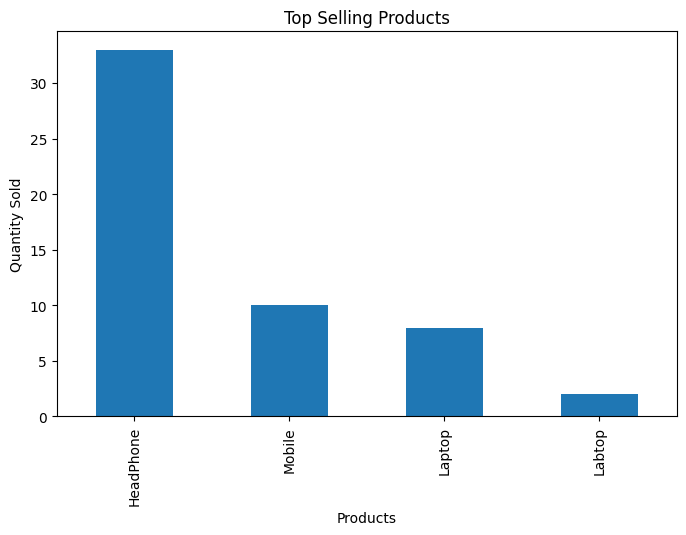


Monthly Revenue:
Month
9     265000
10    484500
Name: Revenue, dtype: int64


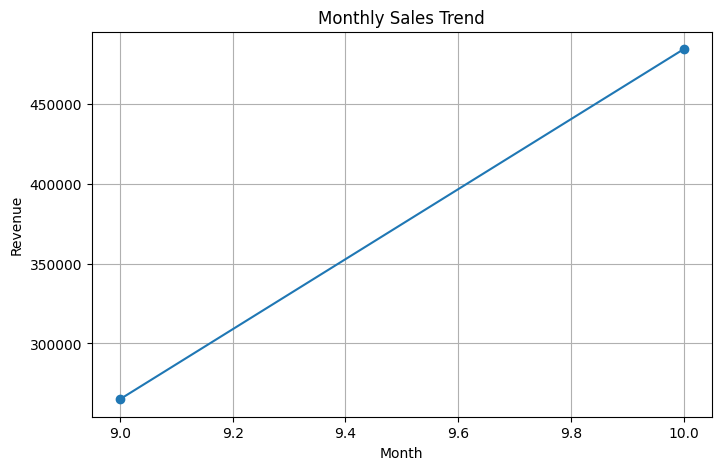


Revenue by Product:
Product
Laptop       400000
Mobile       200000
Labtop       100000
HeadPhone     49500
Name: Revenue, dtype: int64

========== FINAL INSIGHTS ==========
Top Selling Product : HeadPhone
Highest Revenue Generating Product : Laptop
Highest Revenue Month : 10
Highest Monthly Revenue : 484500


In [10]:
# E-Commerce Sales Performance Analysis

# Import Libraries
from google.colab import files
uploaded = files.upload()
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Dataset
df = pd.read_csv('sales_data-1.csv')

# Display First 5 Rows
print("Dataset Preview:")
print(df.head())

# Dataset Information
print("\nDataset Information:")
print(df.info())

# Check Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

# Remove Missing Values
df = df.dropna()

# Remove Duplicate Records
df = df.drop_duplicates()

print("\nDataset Shape After Cleaning:")
print(df.shape)

# Convert Date Column
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

# Create Revenue Column
df['Revenue'] = df['Quantity'] * df['Price']

print("\nDataset After Cleaning:")
print(df.head())

# Top-Selling Products Analysis
top_products = df.groupby('Product')['Quantity'].sum().sort_values(ascending=False)

print("\nTop Selling Products:")
print(top_products)

# Bar Chart for Top-Selling Products
plt.figure(figsize=(8,5))
top_products.plot(kind='bar')
plt.title('Top Selling Products')
plt.xlabel('Products')
plt.ylabel('Quantity Sold')
plt.show()

# Extract Month from Date
df['Month'] = df['Order_Date'].dt.month

# Monthly Revenue Analysis
monthly_sales = df.groupby('Month')['Revenue'].sum()

print("\nMonthly Revenue:")
print(monthly_sales)

# Line Chart for Monthly Sales Trend
plt.figure(figsize=(8,5))
monthly_sales.plot(kind='line', marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.grid(True)
plt.show()

# Best Revenue-Generating Product
best_product = df.groupby('Product')['Revenue'].sum().sort_values(ascending=False)

print("\nRevenue by Product:")
print(best_product)

# Final Insights
print("\n========== FINAL INSIGHTS ==========")
print("Top Selling Product :", top_products.idxmax())
print("Highest Revenue Generating Product :", best_product.idxmax())
print("Highest Revenue Month :", monthly_sales.idxmax())
print("Highest Monthly Revenue :", monthly_sales.max())